<div align="center">

# Laboratorio No. 3

## Clasificación de texto con Naive Bayes

<br>

**Curso:** Natural Language Processing  
**Estudiante:** Jose Tánchez  
**Carné:** 20230005  

<br>

---

### Bolsa de Palabras, TF-IDF y Naive Bayes  
### para clasificación de texto

#### Corpus de noticias en español

</div>

# Introducción

En este laboratorio se utilizará el corpus de noticias preparado y normalizado durante el Laboratorio No. 1.

A partir de la columna de texto normalizado se construirán modelos de clasificación utilizando:

1. **Bolsa de Palabras (BoW).**
2. **TF-IDF.**
3. **Naive Bayes Multinomial.**
4. **Una implementación propia de Naive Bayes.**
5. **Variaciones en el tamaño del vocabulario y el uso de n-gramas.**

El corpus se dividirá en conjuntos de entrenamiento, validación y prueba. Los vectorizadores aprenderán su vocabulario únicamente a partir del conjunto de entrenamiento para evitar fuga de información.

Finalmente, se calcularán métricas de clasificación, matrices de confusión y resultados que permitan comparar las diferentes representaciones y modelos.

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import display

# Buscar el corpus según la ubicación del notebook actual
rutas_posibles = [
    Path("corpus_normalizado.pkl"),
    Path("../Lab1/corpus_normalizado.pkl"),
    Path("Lab1/corpus_normalizado.pkl")
]

ruta_corpus = next(
    (
        ruta
        for ruta in rutas_posibles
        if ruta.exists()
    ),
    None
)

if ruta_corpus is None:
    raise FileNotFoundError(
        "No se encontró 'corpus_normalizado.pkl'. "
        "Guárdalo primero desde el notebook de Lab 1."
    )

corpus = pd.read_pickle(ruta_corpus)

columnas_requeridas = [
    "url",
    "news",
    "Type",
    "tokens_lematizados",
    "News_normalizada"
]

columnas_faltantes = [
    columna
    for columna in columnas_requeridas
    if columna not in corpus.columns
]

if columnas_faltantes:
    raise ValueError(
        f"Faltan columnas necesarias: {columnas_faltantes}"
    )

print(f"Corpus cargado desde: {ruta_corpus.resolve()}")
print(f"Cantidad de documentos: {len(corpus):,}")
print(f"Cantidad de categorías: {corpus['Type'].nunique()}")
print("El corpus está listo para continuar.")

display(corpus[columnas_requeridas].head())

Corpus cargado desde: /Users/josetanchez/Desktop/NLP-Labs-JoseTanchez/Lab1/corpus_normalizado.pkl
Cantidad de documentos: 1,217
Cantidad de categorías: 7
El corpus está listo para continuar.


,url,news,Type,tokens_lematizados,News_normalizada
0,https://www.larepublica.co/redirect/post/3201905,Durante el foro La banca articulador empresari...,Otra,"[foro, banca, articulador, empresarial, desarr...",foro banca articulador empresarial desarrollo ...
1,https://www.larepublica.co/redirect/post/3210288,El regulador de valores de China dijo el domin...,Regulaciones,"[regulador, valor, chino, decir, domingo, busc...",regulador valor chino decir domingo buscar coo...
2,https://www.larepublica.co/redirect/post/3240676,En una industria históricamente masculina como...,Alianzas,"[industria, históricamente, masculino, aviació...",industria históricamente masculino aviación vi...
3,https://www.larepublica.co/redirect/post/3342889,Con el dato de marzo el IPC interanual encaden...,Macroeconomia,"[dato, marzo, ipc, interanual, encadenar, deci...",dato marzo ipc interanual encadenar decimoquin...
4,https://www.larepublica.co/redirect/post/3427208,Ayer en Cartagena se dio inicio a la versión n...,Otra,"[ayer, cartagena, dar, inicio, versión, número...",ayer cartagena dar inicio versión número 56 co...


# 1. Conjuntos de entrenamiento, validación y prueba

El corpus se dividirá en tres conjuntos:

- **Entrenamiento:** 70 % de los documentos.
- **Validación:** 15 % de los documentos.
- **Prueba:** 15 % de los documentos.

La separación se realizará con `train_test_split`, utilizando estratificación sobre la columna `Type` para conservar la distribución de las categorías y un estado aleatorio fijo para que el resultado sea reproducible.

El conjunto de entrenamiento se utilizará para ajustar los vectorizadores y los modelos. Los conjuntos de validación y prueba permanecerán separados durante este proceso para evitar fuga de información.

In [7]:
from sklearn.model_selection import train_test_split

semilla_aleatoria = 42

# Agrupar documentos con el mismo texto normalizado
clave_texto = (
    corpus["News_normalizada"]
    .fillna("")
    .str.strip()
)

tabla_grupos_texto = (
    corpus
    .assign(_clave_texto=clave_texto)
    .groupby("_clave_texto", sort=False)
    .agg(
        Categoria_estratificacion=(
            "Type",
            lambda categorias: categorias.mode().iloc[0]
        ),
        Cantidad_documentos=("Type", "size")
    )
    .reset_index()
)

# Separar los grupos en entrenamiento y conjunto temporal
grupos_entrenamiento, grupos_temporales = train_test_split(
    tabla_grupos_texto,
    test_size=0.30,
    random_state=semilla_aleatoria,
    stratify=tabla_grupos_texto[
        "Categoria_estratificacion"
    ]
)

# Dividir los grupos temporales entre validación y prueba
grupos_validacion, grupos_prueba = train_test_split(
    grupos_temporales,
    test_size=0.50,
    random_state=semilla_aleatoria,
    stratify=grupos_temporales[
        "Categoria_estratificacion"
    ]
)

claves_entrenamiento = set(
    grupos_entrenamiento["_clave_texto"]
)
claves_validacion = set(
    grupos_validacion["_clave_texto"]
)
claves_prueba = set(
    grupos_prueba["_clave_texto"]
)

corpus_entrenamiento = corpus.loc[
    clave_texto.isin(claves_entrenamiento)
].copy()

corpus_validacion = corpus.loc[
    clave_texto.isin(claves_validacion)
].copy()

corpus_prueba = corpus.loc[
    clave_texto.isin(claves_prueba)
].copy()

# Verificar que todos los documentos estén presentes una sola vez
assert (
    len(corpus_entrenamiento)
    + len(corpus_validacion)
    + len(corpus_prueba)
    == len(corpus)
)

intersecciones_texto = {
    "Entrenamiento - Validación": len(
        claves_entrenamiento & claves_validacion
    ),
    "Entrenamiento - Prueba": len(
        claves_entrenamiento & claves_prueba
    ),
    "Validación - Prueba": len(
        claves_validacion & claves_prueba
    )
}

assert all(
    cantidad == 0
    for cantidad in intersecciones_texto.values()
)

resumen_particiones = pd.DataFrame({
    "Conjunto": [
        "Entrenamiento",
        "Validación",
        "Prueba"
    ],
    "Cantidad de documentos": [
        len(corpus_entrenamiento),
        len(corpus_validacion),
        len(corpus_prueba)
    ]
})

resumen_particiones["Porcentaje del corpus"] = (
    resumen_particiones["Cantidad de documentos"]
    / len(corpus)
    * 100
).round(2)

display(resumen_particiones)

print("Textos normalizados compartidos entre conjuntos:")
for comparacion, cantidad in intersecciones_texto.items():
    print(f"{comparacion}: {cantidad}")

,Conjunto,Cantidad de documentos,Porcentaje del corpus
0,Entrenamiento,850,69.84
1,Validación,185,15.20
2,Prueba,182,14.95


Textos normalizados compartidos entre conjuntos:
Entrenamiento - Validación: 0
Entrenamiento - Prueba: 0
Validación - Prueba: 0


## 1.1 Tamaño de los conjuntos

La división estratificada produjo los siguientes conjuntos:

| Conjunto | Cantidad de documentos | Porcentaje del corpus |
|---|---:|---:|
| Entrenamiento | 850 | 69.84 % |
| Validación | 185 | 15.20 % |
| Prueba | 182 | 14.95 % |

Los documentos con el mismo texto normalizado se mantuvieron dentro de un único conjunto. Por esta razón, las proporciones presentan una pequeña diferencia respecto al 70 %, 15 % y 15 % solicitado.

La verificación confirmó que no existen textos normalizados compartidos entre entrenamiento, validación y prueba. Los tres conjuntos conservan en total los **1,217 documentos** del corpus.

In [8]:
# Conservar un orden único de categorías para todo el laboratorio
orden_categorias = (
    corpus["Type"]
    .value_counts()
    .index
    .tolist()
)

distribucion_categorias_conjuntos = pd.DataFrame({
    "Corpus completo": (
        corpus["Type"]
        .value_counts()
        .reindex(orden_categorias)
    ),
    "Entrenamiento": (
        corpus_entrenamiento["Type"]
        .value_counts()
        .reindex(orden_categorias)
    ),
    "Validación": (
        corpus_validacion["Type"]
        .value_counts()
        .reindex(orden_categorias)
    ),
    "Prueba": (
        corpus_prueba["Type"]
        .value_counts()
        .reindex(orden_categorias)
    )
})

distribucion_categorias_conjuntos.index.name = "Categoría"

porcentajes_categorias_conjuntos = (
    distribucion_categorias_conjuntos
    .div(
        distribucion_categorias_conjuntos.sum(axis=0),
        axis=1
    )
    .mul(100)
    .round(2)
)

print("Cantidad de documentos por categoría:")
display(distribucion_categorias_conjuntos)

print("Porcentaje de documentos por categoría:")
display(
    porcentajes_categorias_conjuntos.style.format(
        "{:.2f}%"
    )
)

Cantidad de documentos por categoría:


,Corpus completo,Entrenamiento,Validación,Prueba
Categoría,,,,
Macroeconomia,340,239,51,50
Alianzas,247,173,37,37
Innovacion,195,138,28,29
Regulaciones,142,99,22,21
Sostenibilidad,137,93,23,21
Otra,130,90,20,20
Reputacion,26,18,4,4


Porcentaje de documentos por categoría:


,Corpus completo,Entrenamiento,Validación,Prueba
Categoría,,,,
Macroeconomia,27.94%,28.12%,27.57%,27.47%
Alianzas,20.30%,20.35%,20.00%,20.33%
Innovacion,16.02%,16.24%,15.14%,15.93%
Regulaciones,11.67%,11.65%,11.89%,11.54%
Sostenibilidad,11.26%,10.94%,12.43%,11.54%
Otra,10.68%,10.59%,10.81%,10.99%
Reputacion,2.14%,2.12%,2.16%,2.20%


## 1.2 Distribución de las categorías

La distribución de documentos por categoría en cada conjunto fue la siguiente:

| Categoría | Corpus completo | Entrenamiento | Validación | Prueba |
|---|---:|---:|---:|---:|
| Macroeconomia | 340 | 239 | 51 | 50 |
| Alianzas | 247 | 173 | 37 | 37 |
| Innovacion | 195 | 138 | 28 | 29 |
| Regulaciones | 142 | 99 | 22 | 21 |
| Sostenibilidad | 137 | 93 | 23 | 21 |
| Otra | 130 | 90 | 20 | 20 |
| Reputacion | 26 | 18 | 4 | 4 |

Las siete categorías del corpus están representadas en los conjuntos de entrenamiento, validación y prueba. El orden definido en esta tabla se conservará posteriormente para mostrar las métricas y las matrices de confusión.

# 2. Bolsa de Palabras (Bag of Words)

En esta sección se construirá el modelo base utilizando una representación de **Bolsa de Palabras**, conocida como **Bag of Words (BoW)**.

El vocabulario se aprenderá exclusivamente a partir del texto normalizado del conjunto de entrenamiento mediante `CountVectorizer`. Posteriormente, el mismo vectorizador se utilizará para transformar los conjuntos de validación y prueba sin modificar el vocabulario aprendido.

Cada documento será representado mediante los conteos de sus palabras y las matrices resultantes se utilizarán para entrenar y evaluar un clasificador `MultinomialNB`.

In [9]:
from sklearn.feature_extraction.text import CountVectorizer

textos_entrenamiento = (
    corpus_entrenamiento["News_normalizada"]
    .fillna("")
)

textos_validacion = (
    corpus_validacion["News_normalizada"]
    .fillna("")
)

textos_prueba = (
    corpus_prueba["News_normalizada"]
    .fillna("")
)

# Crear el vectorizador con la misma configuración del Lab 2
vectorizador_bow = CountVectorizer(
    tokenizer=str.split,
    preprocessor=None,
    token_pattern=None,
    lowercase=False
)

# Aprender el vocabulario únicamente con entrenamiento
matriz_bow_entrenamiento = (
    vectorizador_bow.fit_transform(
        textos_entrenamiento
    )
)

# Transformar validación y prueba sin modificar el vocabulario
matriz_bow_validacion = vectorizador_bow.transform(
    textos_validacion
)

matriz_bow_prueba = vectorizador_bow.transform(
    textos_prueba
)

vocabulario_bow = (
    vectorizador_bow.get_feature_names_out()
)

resumen_matrices_bow = pd.DataFrame({
    "Conjunto": [
        "Entrenamiento",
        "Validación",
        "Prueba"
    ],
    "Forma de la matriz": [
        str(matriz_bow_entrenamiento.shape),
        str(matriz_bow_validacion.shape),
        str(matriz_bow_prueba.shape)
    ],
    "Valores distintos de cero": [
        matriz_bow_entrenamiento.nnz,
        matriz_bow_validacion.nnz,
        matriz_bow_prueba.nnz
    ]
})

display(resumen_matrices_bow)

print(
    f"Vocabulario aprendido con entrenamiento: "
    f"{len(vocabulario_bow):,} términos."
)

,Conjunto,Forma de la matriz,Valores distintos de cero
0,Entrenamiento,"(850, 17922)",158555
1,Validación,"(185, 17922)",33381
2,Prueba,"(182, 17922)",33475


Vocabulario aprendido con entrenamiento: 17,922 términos.


## 2.1 Dimensiones de las matrices BoW

El vectorizador aprendió un vocabulario de **17,922 términos** utilizando únicamente el conjunto de entrenamiento.

Las matrices obtenidas tienen las siguientes dimensiones:

| Conjunto | Forma de la matriz | Valores distintos de cero |
|---|---:|---:|
| Entrenamiento | (850, 17,922) | 158,555 |
| Validación | (185, 17,922) | 33,381 |
| Prueba | (182, 17,922) | 33,475 |

Las tres matrices contienen las mismas **17,922 columnas** porque validación y prueba fueron transformadas con el vocabulario aprendido durante el ajuste del conjunto de entrenamiento.

In [10]:
from sklearn.naive_bayes import MultinomialNB

etiquetas_entrenamiento = (
    corpus_entrenamiento["Type"]
)

etiquetas_validacion = (
    corpus_validacion["Type"]
)

etiquetas_prueba = (
    corpus_prueba["Type"]
)

# Entrenar el modelo base con la representación BoW
modelo_bow = MultinomialNB(
    alpha=1.0
)

modelo_bow.fit(
    matriz_bow_entrenamiento,
    etiquetas_entrenamiento
)

print("Modelo MultinomialNB con BoW entrenado correctamente.")
print(f"Parámetro de suavizado alpha: {modelo_bow.alpha}")
print(f"Cantidad de categorías aprendidas: {len(modelo_bow.classes_)}")
print("Categorías aprendidas:")
print(modelo_bow.classes_)

Modelo MultinomialNB con BoW entrenado correctamente.
Parámetro de suavizado alpha: 1.0
Cantidad de categorías aprendidas: 7
Categorías aprendidas:
['Alianzas' 'Innovacion' 'Macroeconomia' 'Otra' 'Regulaciones'
 'Reputacion' 'Sostenibilidad']


## 2.2 Evaluación del modelo BoW

El modelo BoW se evaluará inicialmente sobre los conjuntos de entrenamiento y validación.

Para cada conjunto se calcularán `accuracy`, precisión, recall y F1-score utilizando promedios macro y ponderado. También se generará el `classification_report` con los resultados de cada categoría.

El conjunto de prueba se mantendrá reservado hasta completar la comparación de las representaciones y modelos.

In [11]:
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support
)


def calcular_metricas_clasificacion(
    etiquetas_reales,
    predicciones
):
    """
    Calcula las métricas generales de clasificación.
    """

    precision_macro, recall_macro, f1_macro, _ = (
        precision_recall_fscore_support(
            etiquetas_reales,
            predicciones,
            average="macro",
            zero_division=0
        )
    )

    precision_ponderada, recall_ponderado, f1_ponderado, _ = (
        precision_recall_fscore_support(
            etiquetas_reales,
            predicciones,
            average="weighted",
            zero_division=0
        )
    )

    return {
        "Accuracy": accuracy_score(
            etiquetas_reales,
            predicciones
        ),
        "Precisión macro": precision_macro,
        "Recall macro": recall_macro,
        "F1 macro": f1_macro,
        "Precisión ponderada": precision_ponderada,
        "Recall ponderado": recall_ponderado,
        "F1 ponderado": f1_ponderado
    }


predicciones_bow_entrenamiento = modelo_bow.predict(
    matriz_bow_entrenamiento
)

predicciones_bow_validacion = modelo_bow.predict(
    matriz_bow_validacion
)

resultados_bow = pd.DataFrame([
    {
        "Modelo": "BoW completo",
        "Conjunto": "Entrenamiento",
        **calcular_metricas_clasificacion(
            etiquetas_entrenamiento,
            predicciones_bow_entrenamiento
        )
    },
    {
        "Modelo": "BoW completo",
        "Conjunto": "Validación",
        **calcular_metricas_clasificacion(
            etiquetas_validacion,
            predicciones_bow_validacion
        )
    }
])

display(
    resultados_bow.round(4)
)

,Modelo,Conjunto,Accuracy,Precisión macro,Recall macro,F1 macro,Precisión ponderada,Recall ponderado,F1 ponderado
0,BoW completo,Entrenamiento,0.9435,0.9559,0.9291,0.9398,0.9485,0.9435,0.9438
1,BoW completo,Validación,0.7946,0.8350,0.7089,0.7259,0.8145,0.7946,0.7854


In [12]:
from sklearn.metrics import classification_report

print("REPORTE DE CLASIFICACIÓN — ENTRENAMIENTO\n")

print(
    classification_report(
        etiquetas_entrenamiento,
        predicciones_bow_entrenamiento,
        labels=orden_categorias,
        digits=4,
        zero_division=0
    )
)

print("REPORTE DE CLASIFICACIÓN — VALIDACIÓN\n")

print(
    classification_report(
        etiquetas_validacion,
        predicciones_bow_validacion,
        labels=orden_categorias,
        digits=4,
        zero_division=0
    )
)

REPORTE DE CLASIFICACIÓN — ENTRENAMIENTO

                precision    recall  f1-score   support

 Macroeconomia     0.9502    0.9582    0.9542       239
      Alianzas     0.9939    0.9480    0.9704       173
    Innovacion     0.8364    1.0000    0.9109       138
  Regulaciones     1.0000    0.9293    0.9634        99
Sostenibilidad     0.9368    0.9570    0.9468        93
          Otra     0.9737    0.8222    0.8916        90
    Reputacion     1.0000    0.8889    0.9412        18

      accuracy                         0.9435       850
     macro avg     0.9559    0.9291    0.9398       850
  weighted avg     0.9485    0.9435    0.9438       850

REPORTE DE CLASIFICACIÓN — VALIDACIÓN

                precision    recall  f1-score   support

 Macroeconomia     0.8421    0.9412    0.8889        51
      Alianzas     0.8519    0.6216    0.7188        37
    Innovacion     0.6512    1.0000    0.7887        28
  Regulaciones     0.7368    0.6364    0.6829        22
Sostenibilidad     

## 2.3 Matriz de confusión del modelo BoW

Se construirá la matriz de confusión correspondiente al conjunto de validación para observar la cantidad de predicciones correctas e incorrectas en cada categoría.

Las filas representarán las categorías reales y las columnas representarán las categorías predichas. En ambos ejes se utilizará el orden de categorías definido durante la preparación de los conjuntos.

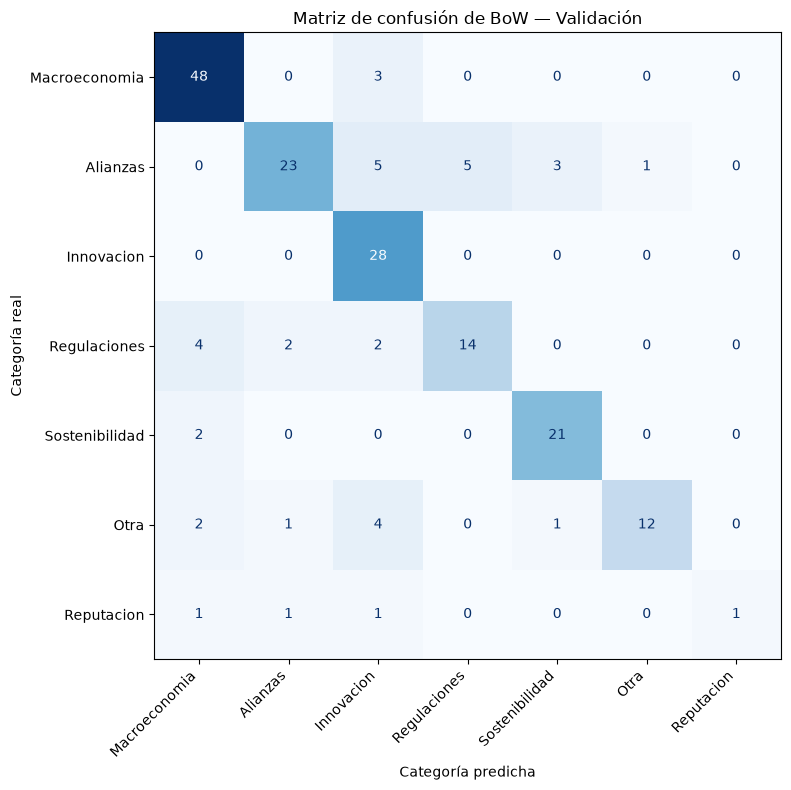

In [13]:
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay
)

matriz_confusion_bow_validacion = confusion_matrix(
    etiquetas_validacion,
    predicciones_bow_validacion,
    labels=orden_categorias
)

fig, ax = plt.subplots(
    figsize=(11, 8)
)

visualizacion_bow = ConfusionMatrixDisplay(
    confusion_matrix=matriz_confusion_bow_validacion,
    display_labels=orden_categorias
)

visualizacion_bow.plot(
    ax=ax,
    cmap="Blues",
    values_format="d",
    colorbar=False
)

plt.title(
    "Matriz de confusión de BoW — Validación"
)
plt.xlabel("Categoría predicha")
plt.ylabel("Categoría real")
plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()

## 2.4 Resultados generales del modelo BoW

Las métricas generales obtenidas con la representación BoW fueron:

| Métrica | Entrenamiento | Validación |
|---|---:|---:|
| Accuracy | 0.9435 | 0.7946 |
| Precisión macro | 0.9559 | 0.8350 |
| Recall macro | 0.9291 | 0.7089 |
| F1 macro | 0.9398 | 0.7259 |
| Precisión ponderada | 0.9485 | 0.8145 |
| Recall ponderado | 0.9435 | 0.7946 |
| F1 ponderado | 0.9438 | 0.7854 |

El `classification_report` y la matriz de confusión conservan el detalle de los resultados por categoría. La evaluación sobre el conjunto de prueba permanece pendiente hasta completar la comparación de modelos.

# 3. TF-IDF

En esta sección se construirá una segunda representación utilizando **TF-IDF**.

El vectorizador aprenderá el vocabulario y los pesos IDF exclusivamente a partir del conjunto de entrenamiento. Posteriormente, se utilizará el mismo objeto para transformar los conjuntos de validación y prueba sin realizar un nuevo ajuste.

Las matrices TF-IDF se utilizarán para entrenar otro clasificador `MultinomialNB`, manteniendo separados los objetos correspondientes a BoW y TF-IDF.

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizador_tfidf = TfidfVectorizer(
    tokenizer=str.split,
    preprocessor=None,
    token_pattern=None,
    lowercase=False
)

# Aprender el vocabulario y los pesos IDF solo con entrenamiento
matriz_tfidf_entrenamiento = (
    vectorizador_tfidf.fit_transform(
        textos_entrenamiento
    )
)

# Transformar validación y prueba sin reajustar el vectorizador
matriz_tfidf_validacion = vectorizador_tfidf.transform(
    textos_validacion
)

matriz_tfidf_prueba = vectorizador_tfidf.transform(
    textos_prueba
)

vocabulario_tfidf = (
    vectorizador_tfidf.get_feature_names_out()
)

resumen_matrices_tfidf = pd.DataFrame({
    "Conjunto": [
        "Entrenamiento",
        "Validación",
        "Prueba"
    ],
    "Forma de la matriz": [
        str(matriz_tfidf_entrenamiento.shape),
        str(matriz_tfidf_validacion.shape),
        str(matriz_tfidf_prueba.shape)
    ],
    "Valores distintos de cero": [
        matriz_tfidf_entrenamiento.nnz,
        matriz_tfidf_validacion.nnz,
        matriz_tfidf_prueba.nnz
    ]
})

display(resumen_matrices_tfidf)

print(
    f"Vocabulario aprendido con entrenamiento: "
    f"{len(vocabulario_tfidf):,} términos."
)

,Conjunto,Forma de la matriz,Valores distintos de cero
0,Entrenamiento,"(850, 17922)",158555
1,Validación,"(185, 17922)",33381
2,Prueba,"(182, 17922)",33475


Vocabulario aprendido con entrenamiento: 17,922 términos.


## 3.1 Dimensiones de las matrices TF-IDF

El vectorizador TF-IDF aprendió un vocabulario de **17,922 términos** utilizando únicamente el conjunto de entrenamiento.

Las matrices obtenidas tienen las siguientes dimensiones:

| Conjunto | Forma de la matriz | Valores distintos de cero |
|---|---:|---:|
| Entrenamiento | (850, 17,922) | 158,555 |
| Validación | (185, 17,922) | 33,381 |
| Prueba | (182, 17,922) | 33,475 |

Las dimensiones y la cantidad de valores distintos de cero coinciden con las matrices BoW porque ambas representaciones utilizan el mismo vocabulario de unigramas. La diferencia se encuentra en los valores almacenados: BoW utiliza conteos y TF-IDF utiliza pesos.

In [15]:
# Entrenar MultinomialNB con la representación TF-IDF
modelo_tfidf = MultinomialNB(
    alpha=1.0
)

modelo_tfidf.fit(
    matriz_tfidf_entrenamiento,
    etiquetas_entrenamiento
)

print("Modelo MultinomialNB con TF-IDF entrenado correctamente.")
print(f"Parámetro de suavizado alpha: {modelo_tfidf.alpha}")
print(f"Cantidad de categorías aprendidas: {len(modelo_tfidf.classes_)}")
print("Categorías aprendidas:")
print(modelo_tfidf.classes_)

Modelo MultinomialNB con TF-IDF entrenado correctamente.
Parámetro de suavizado alpha: 1.0
Cantidad de categorías aprendidas: 7
Categorías aprendidas:
['Alianzas' 'Innovacion' 'Macroeconomia' 'Otra' 'Regulaciones'
 'Reputacion' 'Sostenibilidad']


## 3.2 Evaluación del modelo TF-IDF

El modelo TF-IDF se evaluará sobre los conjuntos de entrenamiento y validación utilizando la misma función y las mismas métricas aplicadas al modelo BoW.

Esto permitirá conservar una estructura uniforme para comparar `accuracy`, precisión, recall y F1-score con promedios macro y ponderado. El conjunto de prueba continuará reservado para la evaluación final.

In [16]:
predicciones_tfidf_entrenamiento = modelo_tfidf.predict(
    matriz_tfidf_entrenamiento
)

predicciones_tfidf_validacion = modelo_tfidf.predict(
    matriz_tfidf_validacion
)

resultados_tfidf = pd.DataFrame([
    {
        "Modelo": "TF-IDF",
        "Conjunto": "Entrenamiento",
        **calcular_metricas_clasificacion(
            etiquetas_entrenamiento,
            predicciones_tfidf_entrenamiento
        )
    },
    {
        "Modelo": "TF-IDF",
        "Conjunto": "Validación",
        **calcular_metricas_clasificacion(
            etiquetas_validacion,
            predicciones_tfidf_validacion
        )
    }
])

display(
    resultados_tfidf.round(4)
)

,Modelo,Conjunto,Accuracy,Precisión macro,Recall macro,F1 macro,Precisión ponderada,Recall ponderado,F1 ponderado
0,TF-IDF,Entrenamiento,0.7047,0.7466,0.5194,0.5163,0.7943,0.7047,0.6483
1,TF-IDF,Validación,0.5892,0.5747,0.4229,0.4066,0.6421,0.5892,0.5215


In [17]:
print("REPORTE DE CLASIFICACIÓN — ENTRENAMIENTO\n")

print(
    classification_report(
        etiquetas_entrenamiento,
        predicciones_tfidf_entrenamiento,
        labels=orden_categorias,
        digits=4,
        zero_division=0
    )
)

print("REPORTE DE CLASIFICACIÓN — VALIDACIÓN\n")

print(
    classification_report(
        etiquetas_validacion,
        predicciones_tfidf_validacion,
        labels=orden_categorias,
        digits=4,
        zero_division=0
    )
)

REPORTE DE CLASIFICACIÓN — ENTRENAMIENTO

                precision    recall  f1-score   support

 Macroeconomia     0.5484    0.9958    0.7073       239
      Alianzas     0.8728    0.8728    0.8728       173
    Innovacion     0.8047    0.9855    0.8860       138
  Regulaciones     1.0000    0.2424    0.3902        99
Sostenibilidad     1.0000    0.4839    0.6522        93
          Otra     1.0000    0.0556    0.1053        90
    Reputacion     0.0000    0.0000    0.0000        18

      accuracy                         0.7047       850
     macro avg     0.7466    0.5194    0.5163       850
  weighted avg     0.7943    0.7047    0.6483       850

REPORTE DE CLASIFICACIÓN — VALIDACIÓN

                precision    recall  f1-score   support

 Macroeconomia     0.4425    0.9804    0.6098        51
      Alianzas     0.7742    0.6486    0.7059        37
    Innovacion     0.8065    0.8929    0.8475        28
  Regulaciones     1.0000    0.0909    0.1667        22
Sostenibilidad     

## 3.3 Matriz de confusión del modelo TF-IDF

Se construirá la matriz de confusión del modelo TF-IDF utilizando el conjunto de validación.

Las filas mostrarán las categorías reales y las columnas las categorías predichas. Se utilizará el mismo orden de clases y la misma configuración visual aplicada a la matriz del modelo BoW.

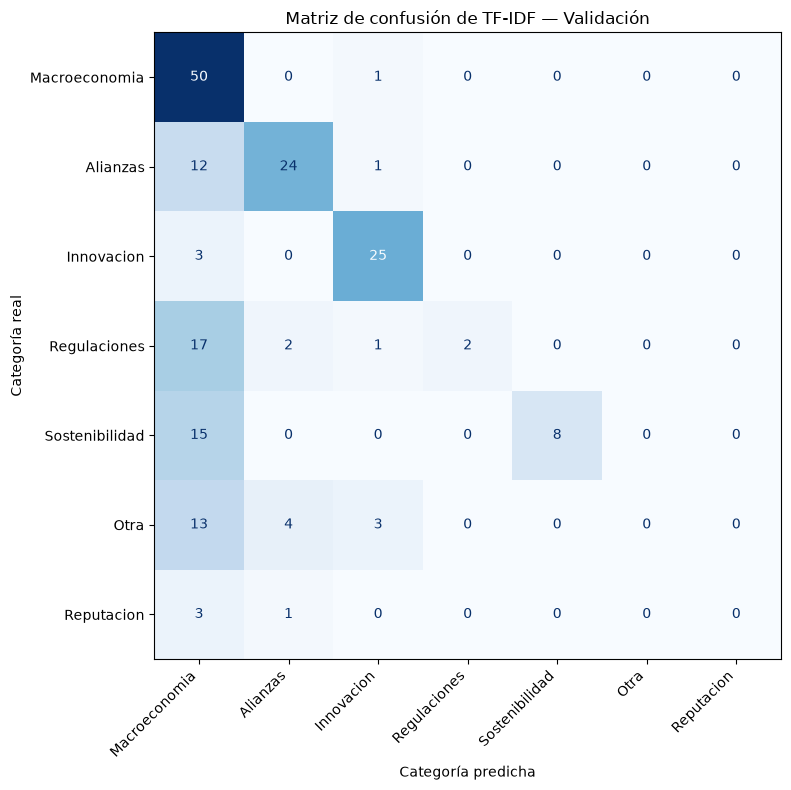

In [18]:
matriz_confusion_tfidf_validacion = confusion_matrix(
    etiquetas_validacion,
    predicciones_tfidf_validacion,
    labels=orden_categorias
)

fig, ax = plt.subplots(
    figsize=(11, 8)
)

visualizacion_tfidf = ConfusionMatrixDisplay(
    confusion_matrix=matriz_confusion_tfidf_validacion,
    display_labels=orden_categorias
)

visualizacion_tfidf.plot(
    ax=ax,
    cmap="Blues",
    values_format="d",
    colorbar=False
)

plt.title(
    "Matriz de confusión de TF-IDF — Validación"
)
plt.xlabel("Categoría predicha")
plt.ylabel("Categoría real")
plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()

## 3.4 Resultados generales del modelo TF-IDF

Las métricas generales obtenidas con la representación TF-IDF fueron:

| Métrica | Entrenamiento | Validación |
|---|---:|---:|
| Accuracy | 0.7047 | 0.5892 |
| Precisión macro | 0.7466 | 0.5747 |
| Recall macro | 0.5194 | 0.4229 |
| F1 macro | 0.5163 | 0.4066 |
| Precisión ponderada | 0.7943 | 0.6421 |
| Recall ponderado | 0.7047 | 0.5892 |
| F1 ponderado | 0.6483 | 0.5215 |

El `classification_report` y la matriz de confusión conservan los resultados detallados por categoría. El conjunto de prueba permanece reservado para la evaluación final.

# 4. Variaciones de la representación BoW

En esta sección se evaluarán diferentes configuraciones de `CountVectorizer` para observar cómo cambian el tamaño del vocabulario y las métricas de clasificación.

Se utilizarán las siguientes representaciones:

1. **BoW con vocabulario completo**, utilizado como modelo base.
2. **BoW con un máximo de 1,000 características.**
3. **BoW con un máximo de 5,000 características.**
4. **Unigramas y bigramas**, utilizando `ngram_range=(1, 2)`.

Cada vectorizador se ajustará exclusivamente con el conjunto de entrenamiento. Las configuraciones se compararán utilizando las métricas obtenidas sobre validación, mientras el conjunto de prueba permanece reservado.

In [19]:
def entrenar_variacion_bow(
    nombre,
    max_features=None,
    ngram_range=(1, 1)
):
    """
    Construye y evalúa una variación de BoW utilizando
    únicamente entrenamiento para ajustar el vocabulario.
    """

    vectorizador = CountVectorizer(
        tokenizer=str.split,
        preprocessor=None,
        token_pattern=None,
        lowercase=False,
        max_features=max_features,
        ngram_range=ngram_range
    )

    matriz_entrenamiento = vectorizador.fit_transform(
        textos_entrenamiento
    )

    matriz_validacion = vectorizador.transform(
        textos_validacion
    )

    modelo = MultinomialNB(
        alpha=1.0
    )

    modelo.fit(
        matriz_entrenamiento,
        etiquetas_entrenamiento
    )

    predicciones_entrenamiento = modelo.predict(
        matriz_entrenamiento
    )

    predicciones_validacion = modelo.predict(
        matriz_validacion
    )

    resultados = pd.DataFrame([
        {
            "Modelo": nombre,
            "Conjunto": "Entrenamiento",
            **calcular_metricas_clasificacion(
                etiquetas_entrenamiento,
                predicciones_entrenamiento
            )
        },
        {
            "Modelo": nombre,
            "Conjunto": "Validación",
            **calcular_metricas_clasificacion(
                etiquetas_validacion,
                predicciones_validacion
            )
        }
    ])

    return {
        "vectorizador": vectorizador,
        "modelo": modelo,
        "matriz_entrenamiento": matriz_entrenamiento,
        "matriz_validacion": matriz_validacion,
        "predicciones_entrenamiento":
            predicciones_entrenamiento,
        "predicciones_validacion":
            predicciones_validacion,
        "tamano_vocabulario":
            len(vectorizador.get_feature_names_out()),
        "resultados": resultados
    }


print("Función para evaluar variaciones de BoW creada correctamente.")

Función para evaluar variaciones de BoW creada correctamente.


## 4.1 BoW con 1,000 características

Se construirá una representación BoW limitada a las **1,000 características más frecuentes** del conjunto de entrenamiento.

El vocabulario reducido se ajustará únicamente con entrenamiento y se utilizará sin modificaciones para transformar validación. Después se entrenará un nuevo modelo `MultinomialNB` con la misma configuración del modelo base.

In [20]:
variacion_bow_1000 = entrenar_variacion_bow(
    nombre="BoW 1,000",
    max_features=1000
)

print(
    "Tamaño del vocabulario:",
    f"{variacion_bow_1000['tamano_vocabulario']:,}"
)

print(
    "Forma de entrenamiento:",
    variacion_bow_1000[
        "matriz_entrenamiento"
    ].shape
)

print(
    "Forma de validación:",
    variacion_bow_1000[
        "matriz_validacion"
    ].shape
)

display(
    variacion_bow_1000[
        "resultados"
    ].round(4)
)

Tamaño del vocabulario: 1,000
Forma de entrenamiento: (850, 1000)
Forma de validación: (185, 1000)


,Modelo,Conjunto,Accuracy,Precisión macro,Recall macro,F1 macro,Precisión ponderada,Recall ponderado,F1 ponderado
0,"BoW 1,000",Entrenamiento,0.8965,0.8866,0.9097,0.8955,0.9031,0.8965,0.8969
1,"BoW 1,000",Validación,0.8162,0.8212,0.8363,0.8251,0.8171,0.8162,0.8124


### Resultados de BoW con 1,000 características

La representación obtuvo matrices de **850 × 1,000** para entrenamiento y **185 × 1,000** para validación.

Las métricas generales fueron:

| Métrica | Entrenamiento | Validación |
|---|---:|---:|
| Accuracy | 0.8965 | 0.8162 |
| Precisión macro | 0.8866 | 0.8212 |
| Recall macro | 0.9097 | 0.8363 |
| F1 macro | 0.8955 | 0.8251 |
| Precisión ponderada | 0.9031 | 0.8171 |
| Recall ponderado | 0.8965 | 0.8162 |
| F1 ponderado | 0.8969 | 0.8124 |

## 4.2 BoW con 5,000 características

Se construirá una segunda representación BoW limitada a las **5,000 características más frecuentes** del conjunto de entrenamiento.

Se conservará el mismo proceso de ajuste, transformación y entrenamiento utilizado en la variante anterior para que los resultados sean comparables.

In [21]:
variacion_bow_5000 = entrenar_variacion_bow(
    nombre="BoW 5,000",
    max_features=5000
)

print(
    "Tamaño del vocabulario:",
    f"{variacion_bow_5000['tamano_vocabulario']:,}"
)

print(
    "Forma de entrenamiento:",
    variacion_bow_5000[
        "matriz_entrenamiento"
    ].shape
)

print(
    "Forma de validación:",
    variacion_bow_5000[
        "matriz_validacion"
    ].shape
)

display(
    variacion_bow_5000[
        "resultados"
    ].round(4)
)

Tamaño del vocabulario: 5,000
Forma de entrenamiento: (850, 5000)
Forma de validación: (185, 5000)


,Modelo,Conjunto,Accuracy,Precisión macro,Recall macro,F1 macro,Precisión ponderada,Recall ponderado,F1 ponderado
0,"BoW 5,000",Entrenamiento,0.9424,0.9443,0.9515,0.9470,0.9454,0.9424,0.9427
1,"BoW 5,000",Validación,0.8324,0.8468,0.8565,0.8459,0.8404,0.8324,0.8295


### Resultados de BoW con 5,000 características

La representación obtuvo matrices de **850 × 5,000** para entrenamiento y **185 × 5,000** para validación.

Las métricas generales fueron:

| Métrica | Entrenamiento | Validación |
|---|---:|---:|
| Accuracy | 0.9424 | 0.8324 |
| Precisión macro | 0.9443 | 0.8468 |
| Recall macro | 0.9515 | 0.8565 |
| F1 macro | 0.9470 | 0.8459 |
| Precisión ponderada | 0.9454 | 0.8404 |
| Recall ponderado | 0.9424 | 0.8324 |
| F1 ponderado | 0.9427 | 0.8295 |

## 4.3 Unigramas y bigramas

Se construirá una representación BoW que incluya palabras individuales y pares de palabras consecutivas mediante `ngram_range=(1, 2)`.

El vocabulario de unigramas y bigramas se aprenderá únicamente con entrenamiento. Después se transformará validación y se entrenará un nuevo clasificador `MultinomialNB` con la misma configuración utilizada en las variantes anteriores.

In [22]:
variacion_bow_unigramas_bigramas = entrenar_variacion_bow(
    nombre="BoW unigramas + bigramas",
    ngram_range=(1, 2)
)

print(
    "Tamaño del vocabulario:",
    f"{variacion_bow_unigramas_bigramas['tamano_vocabulario']:,}"
)

print(
    "Forma de entrenamiento:",
    variacion_bow_unigramas_bigramas[
        "matriz_entrenamiento"
    ].shape
)

print(
    "Forma de validación:",
    variacion_bow_unigramas_bigramas[
        "matriz_validacion"
    ].shape
)

display(
    variacion_bow_unigramas_bigramas[
        "resultados"
    ].round(4)
)

Tamaño del vocabulario: 180,840
Forma de entrenamiento: (850, 180840)
Forma de validación: (185, 180840)


,Modelo,Conjunto,Accuracy,Precisión macro,Recall macro,F1 macro,Precisión ponderada,Recall ponderado,F1 ponderado
0,BoW unigramas + bigramas,Entrenamiento,0.9859,0.9879,0.9708,0.9787,0.9861,0.9859,0.9858
1,BoW unigramas + bigramas,Validación,0.7892,0.7215,0.6616,0.6647,0.8069,0.7892,0.7726


### Resultados de unigramas y bigramas

La representación generó un vocabulario de **180,840 características**. Las matrices obtenidas tienen dimensiones de **850 × 180,840** para entrenamiento y **185 × 180,840** para validación.

Las métricas generales fueron:

| Métrica | Entrenamiento | Validación |
|---|---:|---:|
| Accuracy | 0.9859 | 0.7892 |
| Precisión macro | 0.9879 | 0.7215 |
| Recall macro | 0.9708 | 0.6616 |
| F1 macro | 0.9787 | 0.6647 |
| Precisión ponderada | 0.9861 | 0.8069 |
| Recall ponderado | 0.9859 | 0.7892 |
| F1 ponderado | 0.9858 | 0.7726 |

## 4.4 Comparación de las variaciones BoW

Se consolidarán los resultados obtenidos sobre el conjunto de validación para comparar las cuatro configuraciones de Bolsa de Palabras.

La tabla incluirá el tipo de representación, el tamaño del vocabulario, `accuracy`, F1 macro y F1 ponderado. Esta información se conservará para la comparación final de los modelos.

In [23]:
def obtener_metricas_validacion(resultados):
    fila_validacion = (
        resultados
        .loc[
            resultados["Conjunto"].eq("Validación")
        ]
        .iloc[0]
    )

    return {
        "Accuracy": fila_validacion["Accuracy"],
        "Precisión macro":
            fila_validacion["Precisión macro"],
        "Recall macro":
            fila_validacion["Recall macro"],
        "F1 macro": fila_validacion["F1 macro"],
        "F1 ponderado":
            fila_validacion["F1 ponderado"]
    }


comparacion_variaciones_bow = pd.DataFrame([
    {
        "Representación": "BoW vocabulario completo",
        "Tamaño del vocabulario":
            len(vocabulario_bow),
        **obtener_metricas_validacion(
            resultados_bow
        )
    },
    {
        "Representación": "BoW 1,000",
        "Tamaño del vocabulario":
            variacion_bow_1000[
                "tamano_vocabulario"
            ],
        **obtener_metricas_validacion(
            variacion_bow_1000["resultados"]
        )
    },
    {
        "Representación": "BoW 5,000",
        "Tamaño del vocabulario":
            variacion_bow_5000[
                "tamano_vocabulario"
            ],
        **obtener_metricas_validacion(
            variacion_bow_5000["resultados"]
        )
    },
    {
        "Representación": "BoW unigramas + bigramas",
        "Tamaño del vocabulario":
            variacion_bow_unigramas_bigramas[
                "tamano_vocabulario"
            ],
        **obtener_metricas_validacion(
            variacion_bow_unigramas_bigramas[
                "resultados"
            ]
        )
    }
])

display(
    comparacion_variaciones_bow.round({
        "Accuracy": 4,
        "Precisión macro": 4,
        "Recall macro": 4,
        "F1 macro": 4,
        "F1 ponderado": 4
    })
)

,Representación,Tamaño del vocabulario,Accuracy,Precisión macro,Recall macro,F1 macro,F1 ponderado
0,BoW vocabulario completo,17922,0.7946,0.8350,0.7089,0.7259,0.7854
1,"BoW 1,000",1000,0.8162,0.8212,0.8363,0.8251,0.8124
2,"BoW 5,000",5000,0.8324,0.8468,0.8565,0.8459,0.8295
3,BoW unigramas + bigramas,180840,0.7892,0.7215,0.6616,0.6647,0.7726


### Resultados de la comparación BoW

Las métricas obtenidas sobre el conjunto de validación fueron:

| Representación | Tamaño del vocabulario | Accuracy | Precisión macro | Recall macro | F1 macro | F1 ponderado |
|---|---:|---:|---:|---:|---:|---:|
| BoW vocabulario completo | 17,922 | 0.7946 | 0.8350 | 0.7089 | 0.7259 | 0.7854 |
| BoW 1,000 | 1,000 | 0.8162 | 0.8212 | 0.8363 | 0.8251 | 0.8124 |
| BoW 5,000 | 5,000 | 0.8324 | 0.8468 | 0.8565 | 0.8459 | 0.8295 |
| BoW unigramas + bigramas | 180,840 | 0.7892 | 0.7215 | 0.6616 | 0.6647 | 0.7726 |

Esta tabla conserva los resultados necesarios para seleccionar posteriormente una configuración mediante el conjunto de validación.

# 5. Implementación propia de Naive Bayes

En esta sección se implementará un clasificador Naive Bayes Multinomial utilizando NumPy.

La implementación calculará:

1. Las probabilidades previas de cada categoría, \(P(c)\).
2. Las probabilidades condicionales de cada término, \(P(w_i \mid c)\).
3. El suavizado de Laplace mediante `alpha=1.0`.
4. Los logaritmos de las probabilidades para realizar las predicciones.

Se utilizarán las matrices BoW con vocabulario completo para comparar la implementación propia con `MultinomialNB` bajo la misma representación y los mismos datos.

In [24]:
import numpy as np


class NaiveBayesMultinomialPropio:
    """
    Implementación propia de Naive Bayes Multinomial.
    """

    def __init__(self, alpha=1.0):
        self.alpha = alpha

    def fit(self, matriz, etiquetas):
        etiquetas_array = np.asarray(etiquetas)

        self.clases_, conteos_clases = np.unique(
            etiquetas_array,
            return_counts=True
        )

        cantidad_documentos = matriz.shape[0]
        cantidad_caracteristicas = matriz.shape[1]

        # Calcular P(c)
        self.probabilidades_previas_ = (
            conteos_clases
            / cantidad_documentos
        )

        self.log_probabilidades_previas_ = np.log(
            self.probabilidades_previas_
        )

        self.probabilidades_condicionales_ = np.zeros(
            (
                len(self.clases_),
                cantidad_caracteristicas
            ),
            dtype=float
        )

        # Calcular P(w_i | c) con suavizado de Laplace
        for posicion, categoria in enumerate(
            self.clases_
        ):
            mascara_categoria = (
                etiquetas_array == categoria
            )

            conteos_palabras = np.asarray(
                matriz[mascara_categoria].sum(axis=0)
            ).ravel()

            total_palabras_categoria = (
                conteos_palabras.sum()
            )

            numerador = (
                conteos_palabras
                + self.alpha
            )

            denominador = (
                total_palabras_categoria
                + self.alpha
                * cantidad_caracteristicas
            )

            self.probabilidades_condicionales_[
                posicion
            ] = numerador / denominador

        self.log_probabilidades_condicionales_ = np.log(
            self.probabilidades_condicionales_
        )

        return self

    def calcular_puntajes_logaritmicos(
        self,
        matriz
    ):
        return (
            matriz
            @ self.log_probabilidades_condicionales_.T
            + self.log_probabilidades_previas_
        )

    def predict(self, matriz):
        puntajes = self.calcular_puntajes_logaritmicos(
            matriz
        )

        posiciones_predichas = np.argmax(
            puntajes,
            axis=1
        )

        return self.clases_[
            posiciones_predichas
        ]

    def predict_proba(self, matriz):
        puntajes = self.calcular_puntajes_logaritmicos(
            matriz
        )

        # Estabilizar la exponenciación
        puntajes_ajustados = (
            puntajes
            - puntajes.max(axis=1, keepdims=True)
        )

        probabilidades = np.exp(
            puntajes_ajustados
        )

        return (
            probabilidades
            / probabilidades.sum(
                axis=1,
                keepdims=True
            )
        )


print("Clase NaiveBayesMultinomialPropio creada correctamente.")

Clase NaiveBayesMultinomialPropio creada correctamente.


In [25]:
modelo_bow_propio = NaiveBayesMultinomialPropio(
    alpha=1.0
)

modelo_bow_propio.fit(
    matriz_bow_entrenamiento,
    etiquetas_entrenamiento
)

conteos_entrenamiento_por_categoria = (
    etiquetas_entrenamiento
    .value_counts()
    .reindex(modelo_bow_propio.clases_)
    .to_numpy()
)

tabla_probabilidades_previas = pd.DataFrame({
    "Categoría": modelo_bow_propio.clases_,
    "Documentos de entrenamiento":
        conteos_entrenamiento_por_categoria,
    "P(c)":
        modelo_bow_propio.probabilidades_previas_,
    "log P(c)":
        modelo_bow_propio.log_probabilidades_previas_
})

display(
    tabla_probabilidades_previas.round({
        "P(c)": 6,
        "log P(c)": 6
    })
)

print(
    "Suma de las probabilidades previas:",
    modelo_bow_propio.probabilidades_previas_.sum()
)

,Categoría,Documentos de entrenamiento,P(c),log P(c)
0,Alianzas,173,0.203529,-1.591945
1,Innovacion,138,0.162353,-1.817983
2,Macroeconomia,239,0.281176,-1.268773
3,Otra,90,0.105882,-2.245427
4,Regulaciones,99,0.116471,-2.150116
5,Reputacion,18,0.021176,-3.854865
6,Sostenibilidad,93,0.109412,-2.212637


Suma de las probabilidades previas: 0.9999999999999998


## 5.1 Probabilidades previas de las categorías

Las probabilidades previas \(P(c)\) se calcularon a partir de la proporción de documentos de cada categoría en el conjunto de entrenamiento.

| Categoría | Documentos | P(c) | log P(c) |
|---|---:|---:|---:|
| Alianzas | 173 | 0.203529 | -1.591945 |
| Innovacion | 138 | 0.162353 | -1.817983 |
| Macroeconomia | 239 | 0.281176 | -1.268773 |
| Otra | 90 | 0.105882 | -2.245427 |
| Regulaciones | 99 | 0.116471 | -2.150116 |
| Reputacion | 18 | 0.021176 | -3.854865 |
| Sostenibilidad | 93 | 0.109412 | -2.212637 |

La suma de las probabilidades previas es aproximadamente **1**, considerando la precisión de punto flotante.

## 5.2 Probabilidades condicionales de las palabras

A partir de los conteos BoW se obtuvieron las probabilidades condicionales \(P(w_i \mid c)\) para cada término y categoría.

El cálculo utiliza suavizado de Laplace con `alpha=1.0`, por lo que todos los términos del vocabulario reciben una probabilidad mayor que cero. Para comprobar los resultados se mostrarán las palabras con mayor probabilidad condicional dentro de cada categoría.

In [26]:
cantidad_palabras_por_categoria = 10
palabras_probables_por_categoria = []

for posicion, categoria in enumerate(
    modelo_bow_propio.clases_
):
    probabilidades_categoria = (
        modelo_bow_propio
        .probabilidades_condicionales_[
            posicion
        ]
    )

    indices_mayores = np.argsort(
        -probabilidades_categoria,
        kind="stable"
    )[:cantidad_palabras_por_categoria]

    for rango, indice_palabra in enumerate(
        indices_mayores,
        start=1
    ):
        palabras_probables_por_categoria.append({
            "Categoría": categoria,
            "Posición": rango,
            "Palabra": vocabulario_bow[
                indice_palabra
            ],
            "P(w_i | c)": probabilidades_categoria[
                indice_palabra
            ],
            "log P(w_i | c)": (
                modelo_bow_propio
                .log_probabilidades_condicionales_[
                    posicion,
                    indice_palabra
                ]
            )
        })

tabla_palabras_probables = pd.DataFrame(
    palabras_probables_por_categoria
)

display(
    tabla_palabras_probables.round({
        "P(w_i | c)": 8,
        "log P(w_i | c)": 6
    })
)

sumas_probabilidades_condicionales = (
    modelo_bow_propio
    .probabilidades_condicionales_
    .sum(axis=1)
)

print(
    "Suma de P(w_i | c) por categoría:"
)

for categoria, suma in zip(
    modelo_bow_propio.clases_,
    sumas_probabilidades_condicionales
):
    print(f"{categoria}: {suma:.12f}")

,Categoría,Posición,Palabra,P(w_i | c),log P(w_i | c)
0,Alianzas,1,alianza,0.005511,-5.200995
1,Alianzas,2,país,0.004655,-5.369894
2,Alianzas,3,poder,0.004468,-5.410716
3,Alianzas,4,millón,0.004357,-5.436033
4,Alianzas,5,colombia,0.003947,-5.534768
...,...,...,...,...,...
65,Sostenibilidad,6,año,0.003314,-5.709715
66,Sostenibilidad,7,sostenibilidad,0.002744,-5.898509
67,Sostenibilidad,8,eléctrico,0.002726,-5.905023
68,Sostenibilidad,9,agua,0.002637,-5.938249


Suma de P(w_i | c) por categoría:
Alianzas: 1.000000000000
Innovacion: 1.000000000000
Macroeconomia: 1.000000000000
Otra: 1.000000000000
Regulaciones: 1.000000000000
Reputacion: 1.000000000000
Sostenibilidad: 1.000000000000


## 5.3 Evaluación de la implementación propia

La implementación propia se utilizará para predecir las categorías de los conjuntos de entrenamiento y validación a partir de las matrices BoW con vocabulario completo.

Las predicciones se evaluarán con las mismas métricas utilizadas anteriormente. Después se compararán directamente con los resultados de `MultinomialNB` para comprobar que ambos modelos utilizan los mismos cálculos.

In [27]:
predicciones_bow_propio_entrenamiento = (
    modelo_bow_propio.predict(
        matriz_bow_entrenamiento
    )
)

predicciones_bow_propio_validacion = (
    modelo_bow_propio.predict(
        matriz_bow_validacion
    )
)

resultados_bow_propio = pd.DataFrame([
    {
        "Modelo": "Naive Bayes propio",
        "Conjunto": "Entrenamiento",
        **calcular_metricas_clasificacion(
            etiquetas_entrenamiento,
            predicciones_bow_propio_entrenamiento
        )
    },
    {
        "Modelo": "Naive Bayes propio",
        "Conjunto": "Validación",
        **calcular_metricas_clasificacion(
            etiquetas_validacion,
            predicciones_bow_propio_validacion
        )
    }
])

display(
    resultados_bow_propio.round(4)
)

,Modelo,Conjunto,Accuracy,Precisión macro,Recall macro,F1 macro,Precisión ponderada,Recall ponderado,F1 ponderado
0,Naive Bayes propio,Entrenamiento,0.9435,0.9559,0.9291,0.9398,0.9485,0.9435,0.9438
1,Naive Bayes propio,Validación,0.7946,0.8350,0.7089,0.7259,0.8145,0.7946,0.7854


In [28]:
if not np.array_equal(
    modelo_bow.classes_,
    modelo_bow_propio.clases_
):
    raise ValueError(
        "Los modelos utilizan órdenes de categorías diferentes."
    )

coincidencias_entrenamiento = np.sum(
    predicciones_bow_entrenamiento
    == predicciones_bow_propio_entrenamiento
)

coincidencias_validacion = np.sum(
    predicciones_bow_validacion
    == predicciones_bow_propio_validacion
)

comparacion_predicciones = pd.DataFrame({
    "Conjunto": [
        "Entrenamiento",
        "Validación"
    ],
    "Predicciones coincidentes": [
        coincidencias_entrenamiento,
        coincidencias_validacion
    ],
    "Cantidad de documentos": [
        len(etiquetas_entrenamiento),
        len(etiquetas_validacion)
    ]
})

comparacion_predicciones["Coincidencia (%)"] = (
    comparacion_predicciones[
        "Predicciones coincidentes"
    ]
    / comparacion_predicciones[
        "Cantidad de documentos"
    ]
    * 100
)

diferencia_log_probabilidades_previas = np.max(
    np.abs(
        modelo_bow.class_log_prior_
        - modelo_bow_propio.log_probabilidades_previas_
    )
)

diferencia_log_probabilidades_condicionales = np.max(
    np.abs(
        modelo_bow.feature_log_prob_
        - modelo_bow_propio
        .log_probabilidades_condicionales_
    )
)

display(
    comparacion_predicciones.round({
        "Coincidencia (%)": 4
    })
)

print(
    "Diferencia máxima en log P(c):",
    f"{diferencia_log_probabilidades_previas:.12e}"
)

print(
    "Diferencia máxima en log P(w_i | c):",
    f"{diferencia_log_probabilidades_condicionales:.12e}"
)

,Conjunto,Predicciones coincidentes,Cantidad de documentos,Coincidencia (%)
0,Entrenamiento,850,850,100.0
1,Validación,185,185,100.0


Diferencia máxima en log P(c): 4.440892098501e-16
Diferencia máxima en log P(w_i | c): 1.776356839400e-15


## 5.4 Comparación con MultinomialNB

La implementación propia y `MultinomialNB` produjeron las mismas predicciones en los conjuntos evaluados:

| Conjunto | Predicciones coincidentes | Documentos | Coincidencia |
|---|---:|---:|---:|
| Entrenamiento | 850 | 850 | 100 % |
| Validación | 185 | 185 | 100 % |

Las diferencias numéricas máximas entre los parámetros calculados fueron:

- **log P(c):** \(4.440892098501 \ 10^{-16}\)
- **log P(w_i \mid c):** \(1.776356839400 \ 10^{-15}\)

Estas diferencias corresponden a la precisión de las operaciones de punto flotante. Las métricas de clasificación obtenidas por ambas implementaciones también fueron iguales.

# 6. Selección del modelo y evaluación final

Las configuraciones se compararán utilizando el **F1 macro de validación**, ya que esta métrica considera por igual el desempeño de las siete categorías.

Después de identificar programáticamente la configuración con el mayor F1 macro, se utilizará el conjunto de prueba por primera vez. En esta etapa también se obtendrán las métricas de prueba de los modelos base BoW y TF-IDF, junto con la implementación propia.

In [29]:
comparacion_representaciones_validacion = pd.concat(
    [
        comparacion_variaciones_bow,
        pd.DataFrame([
            {
                "Representación": "TF-IDF",
                "Tamaño del vocabulario":
                    len(vocabulario_tfidf),
                **obtener_metricas_validacion(
                    resultados_tfidf
                )
            }
        ])
    ],
    ignore_index=True
)

indice_mejor_representacion = (
    comparacion_representaciones_validacion[
        "F1 macro"
    ].idxmax()
)

mejor_representacion = (
    comparacion_representaciones_validacion
    .loc[indice_mejor_representacion]
)

display(
    comparacion_representaciones_validacion.round({
        "Accuracy": 4,
        "Precisión macro": 4,
        "Recall macro": 4,
        "F1 macro": 4,
        "F1 ponderado": 4
    })
)

print(
    "Representación seleccionada:",
    mejor_representacion["Representación"]
)

print(
    "F1 macro de validación:",
    f"{mejor_representacion['F1 macro']:.4f}"
)

,Representación,Tamaño del vocabulario,Accuracy,Precisión macro,Recall macro,F1 macro,F1 ponderado
0,BoW vocabulario completo,17922,0.7946,0.8350,0.7089,0.7259,0.7854
1,"BoW 1,000",1000,0.8162,0.8212,0.8363,0.8251,0.8124
2,"BoW 5,000",5000,0.8324,0.8468,0.8565,0.8459,0.8295
3,BoW unigramas + bigramas,180840,0.7892,0.7215,0.6616,0.6647,0.7726
4,TF-IDF,17922,0.5892,0.5747,0.4229,0.4066,0.5215


Representación seleccionada: BoW 5,000
F1 macro de validación: 0.8459


## 6.1 Representación seleccionada

La comparación mediante el conjunto de validación seleccionó la configuración **BoW con 5,000 características**.

Esta representación obtuvo un **F1 macro de 0.8459** en validación, el valor más alto entre las cinco configuraciones evaluadas. Por lo tanto, será la variante utilizada como modelo seleccionado durante la evaluación final sobre prueba.

In [30]:
# Transformar prueba con el vectorizador de la variante seleccionada
matriz_bow_5000_prueba = (
    variacion_bow_5000[
        "vectorizador"
    ].transform(
        textos_prueba
    )
)

# Generar predicciones finales
predicciones_bow_prueba = modelo_bow.predict(
    matriz_bow_prueba
)

predicciones_tfidf_prueba = modelo_tfidf.predict(
    matriz_tfidf_prueba
)

predicciones_bow_5000_prueba = (
    variacion_bow_5000[
        "modelo"
    ].predict(
        matriz_bow_5000_prueba
    )
)

predicciones_bow_propio_prueba = (
    modelo_bow_propio.predict(
        matriz_bow_prueba
    )
)

resultados_prueba = pd.DataFrame([
    {
        "Modelo": "BoW completo — sklearn",
        **calcular_metricas_clasificacion(
            etiquetas_prueba,
            predicciones_bow_prueba
        )
    },
    {
        "Modelo": "TF-IDF — sklearn",
        **calcular_metricas_clasificacion(
            etiquetas_prueba,
            predicciones_tfidf_prueba
        )
    },
    {
        "Modelo": "BoW 5,000 — seleccionado",
        **calcular_metricas_clasificacion(
            etiquetas_prueba,
            predicciones_bow_5000_prueba
        )
    },
    {
        "Modelo": "BoW completo — propio",
        **calcular_metricas_clasificacion(
            etiquetas_prueba,
            predicciones_bow_propio_prueba
        )
    }
])

display(
    resultados_prueba.round(4)
)

,Modelo,Accuracy,Precisión macro,Recall macro,F1 macro,Precisión ponderada,Recall ponderado,F1 ponderado
0,BoW completo — sklearn,0.8077,0.8547,0.7154,0.7305,0.8374,0.8077,0.7985
1,TF-IDF — sklearn,0.5714,0.2797,0.3800,0.3141,0.3992,0.5714,0.4564
2,"BoW 5,000 — seleccionado",0.8516,0.8583,0.8674,0.8586,0.8575,0.8516,0.8501
3,BoW completo — propio,0.8077,0.8547,0.7154,0.7305,0.8374,0.8077,0.7985


## 6.2 Resultados sobre el conjunto de prueba

Las métricas finales obtenidas sobre los **182 documentos** de prueba fueron:

| Modelo | Accuracy | Precisión macro | Recall macro | F1 macro | Precisión ponderada | Recall ponderado | F1 ponderado |
|---|---:|---:|---:|---:|---:|---:|---:|
| BoW completo — sklearn | 0.8077 | 0.8547 | 0.7154 | 0.7305 | 0.8374 | 0.8077 | 0.7985 |
| TF-IDF — sklearn | 0.5714 | 0.2797 | 0.3800 | 0.3141 | 0.3992 | 0.5714 | 0.4564 |
| BoW 5,000 — seleccionado | 0.8516 | 0.8583 | 0.8674 | 0.8586 | 0.8575 | 0.8516 | 0.8501 |
| BoW completo — propio | 0.8077 | 0.8547 | 0.7154 | 0.7305 | 0.8374 | 0.8077 | 0.7985 |

La implementación propia volvió a producir las mismas métricas que `MultinomialNB` al utilizar la representación BoW completa.

## 6.3 Reportes de clasificación sobre prueba

Se generarán los reportes por categoría para los modelos BoW completo, TF-IDF y BoW con 5,000 características.

La implementación propia no se repetirá en esta tabla porque sus predicciones y métricas coinciden con las del modelo BoW completo de scikit-learn.

In [31]:
reportes_prueba = [
    (
        "BoW COMPLETO — SKLEARN",
        predicciones_bow_prueba
    ),
    (
        "TF-IDF — SKLEARN",
        predicciones_tfidf_prueba
    ),
    (
        "BoW 5,000 — SELECCIONADO",
        predicciones_bow_5000_prueba
    )
]

for nombre_modelo, predicciones in reportes_prueba:
    print(f"{nombre_modelo}\n")

    print(
        classification_report(
            etiquetas_prueba,
            predicciones,
            labels=orden_categorias,
            digits=4,
            zero_division=0
        )
    )

BoW COMPLETO — SKLEARN

                precision    recall  f1-score   support

 Macroeconomia     0.8980    0.8800    0.8889        50
      Alianzas     0.8333    0.8108    0.8219        37
    Innovacion     0.6591    1.0000    0.7945        29
  Regulaciones     1.0000    0.7619    0.8649        21
Sostenibilidad     0.7037    0.9048    0.7917        21
          Otra     0.8889    0.4000    0.5517        20
    Reputacion     1.0000    0.2500    0.4000         4

      accuracy                         0.8077       182
     macro avg     0.8547    0.7154    0.7305       182
  weighted avg     0.8374    0.8077    0.7985       182

TF-IDF — SKLEARN

                precision    recall  f1-score   support

 Macroeconomia     0.4495    0.9800    0.6164        50
      Alianzas     0.8056    0.7838    0.7945        37
    Innovacion     0.7027    0.8966    0.7879        29
  Regulaciones     0.0000    0.0000    0.0000        21
Sostenibilidad     0.0000    0.0000    0.0000        21
  

## 6.4 Matrices de confusión sobre prueba

Se generarán matrices de confusión para BoW completo, TF-IDF y la representación BoW con 5,000 características.

Todas las matrices utilizarán el mismo orden de categorías. Las filas representarán las clases reales y las columnas las clases predichas.

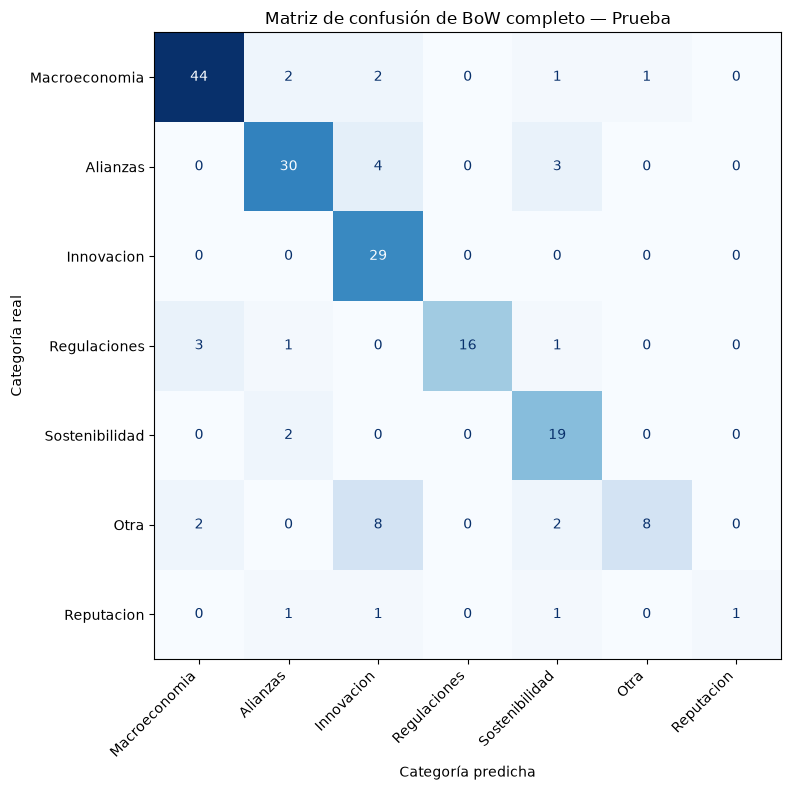

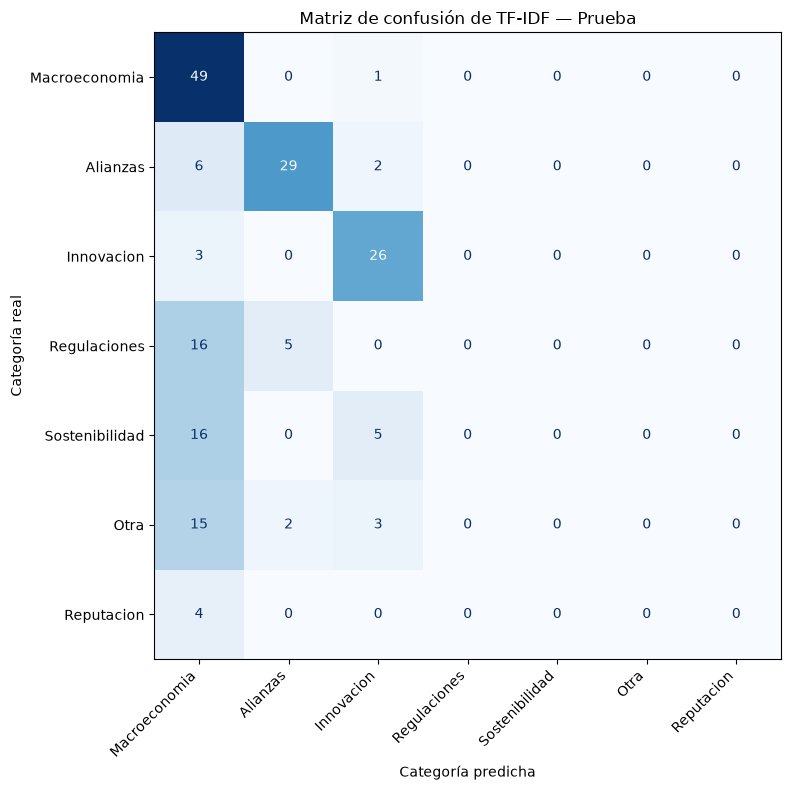

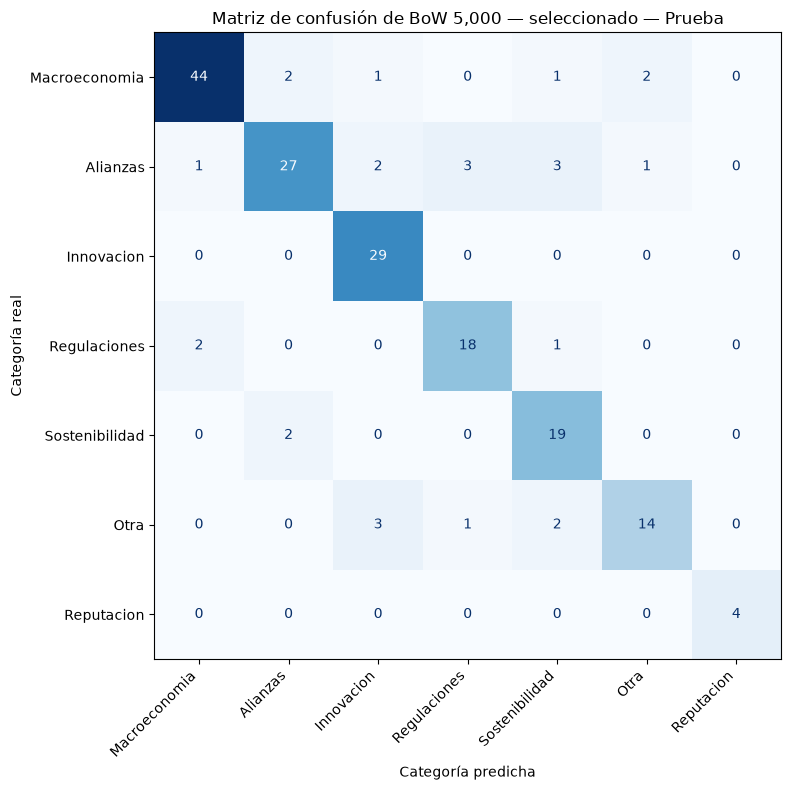

In [32]:
modelos_matrices_prueba = [
    (
        "BoW completo",
        predicciones_bow_prueba
    ),
    (
        "TF-IDF",
        predicciones_tfidf_prueba
    ),
    (
        "BoW 5,000 — seleccionado",
        predicciones_bow_5000_prueba
    )
]

matrices_confusion_prueba = {}

for nombre_modelo, predicciones in modelos_matrices_prueba:
    matriz_confusion = confusion_matrix(
        etiquetas_prueba,
        predicciones,
        labels=orden_categorias
    )

    matrices_confusion_prueba[
        nombre_modelo
    ] = matriz_confusion

    fig, ax = plt.subplots(
        figsize=(11, 8)
    )

    visualizacion = ConfusionMatrixDisplay(
        confusion_matrix=matriz_confusion,
        display_labels=orden_categorias
    )

    visualizacion.plot(
        ax=ax,
        cmap="Blues",
        values_format="d",
        colorbar=False
    )

    plt.title(
        f"Matriz de confusión de {nombre_modelo} — Prueba"
    )
    plt.xlabel("Categoría predicha")
    plt.ylabel("Categoría real")
    plt.xticks(
        rotation=45,
        ha="right"
    )

    plt.tight_layout()
    plt.show()

# 7. Análisis computacional de errores

El análisis de errores se realizará sobre el modelo seleccionado, **BoW con 5,000 características**, utilizando las predicciones del conjunto de prueba.

Mediante código se obtendrán:

1. Las confusiones más frecuentes entre categorías diferentes.
2. Los índices de los documentos clasificados incorrectamente.
3. El texto original y normalizado de esos documentos.
4. La categoría real y la categoría predicha.
5. Las características relevantes para las categorías involucradas.

Esta sección se limitará a producir resultados cuantitativos y ejemplos, sin desarrollar todavía su interpretación académica.

In [33]:
matriz_confusion_modelo_seleccionado = (
    matrices_confusion_prueba[
        "BoW 5,000 — seleccionado"
    ]
)

cantidad_errores = (
    matriz_confusion_modelo_seleccionado.sum()
    - np.trace(
        matriz_confusion_modelo_seleccionado
    )
)

confusiones_modelo_seleccionado = []

for fila, categoria_real in enumerate(
    orden_categorias
):
    for columna, categoria_predicha in enumerate(
        orden_categorias
    ):
        if fila == columna:
            continue

        cantidad = (
            matriz_confusion_modelo_seleccionado[
                fila,
                columna
            ]
        )

        if cantidad > 0:
            confusiones_modelo_seleccionado.append({
                "Categoría real": categoria_real,
                "Categoría predicha":
                    categoria_predicha,
                "Cantidad de documentos":
                    int(cantidad)
            })

tabla_confusiones_frecuentes = (
    pd.DataFrame(
        confusiones_modelo_seleccionado
    )
    .sort_values(
        "Cantidad de documentos",
        ascending=False
    )
    .reset_index(drop=True)
)

tabla_confusiones_frecuentes[
    "Porcentaje de los errores"
] = (
    tabla_confusiones_frecuentes[
        "Cantidad de documentos"
    ]
    / cantidad_errores
    * 100
).round(2)

tabla_confusiones_frecuentes.index = range(
    1,
    len(tabla_confusiones_frecuentes) + 1
)

tabla_confusiones_frecuentes.index.name = "Posición"

print(
    f"Cantidad total de errores: {cantidad_errores}"
)

display(
    tabla_confusiones_frecuentes
)

Cantidad total de errores: 27


,Categoría real,Categoría predicha,Cantidad de documentos,Porcentaje de los errores
Posición,,,,
1,Alianzas,Regulaciones,3,11.11
2,Alianzas,Sostenibilidad,3,11.11
3,Otra,Innovacion,3,11.11
4,Macroeconomia,Alianzas,2,7.41
5,Macroeconomia,Otra,2,7.41
6,Alianzas,Innovacion,2,7.41
7,Regulaciones,Macroeconomia,2,7.41
8,Sostenibilidad,Alianzas,2,7.41
9,Otra,Sostenibilidad,2,7.41


## 7.1 Confusiones frecuentes

El modelo seleccionado clasificó incorrectamente **27 de los 182 documentos** del conjunto de prueba.

Las confusiones observadas fueron:

| Categoría real | Categoría predicha | Documentos | Porcentaje de los errores |
|---|---|---:|---:|
| Alianzas | Regulaciones | 3 | 11.11 % |
| Alianzas | Sostenibilidad | 3 | 11.11 % |
| Otra | Innovacion | 3 | 11.11 % |
| Macroeconomia | Alianzas | 2 | 7.41 % |
| Macroeconomia | Otra | 2 | 7.41 % |
| Alianzas | Innovacion | 2 | 7.41 % |
| Regulaciones | Macroeconomia | 2 | 7.41 % |
| Sostenibilidad | Alianzas | 2 | 7.41 % |
| Otra | Sostenibilidad | 2 | 7.41 % |
| Macroeconomia | Innovacion | 1 | 3.70 % |
| Macroeconomia | Sostenibilidad | 1 | 3.70 % |
| Alianzas | Macroeconomia | 1 | 3.70 % |
| Alianzas | Otra | 1 | 3.70 % |
| Regulaciones | Sostenibilidad | 1 | 3.70 % |
| Otra | Regulaciones | 1 | 3.70 % |

In [34]:
mascara_errores_prueba = (
    etiquetas_prueba.to_numpy()
    != predicciones_bow_5000_prueba
)

probabilidades_bow_5000_prueba = (
    variacion_bow_5000[
        "modelo"
    ].predict_proba(
        matriz_bow_5000_prueba
    )
)

documentos_mal_clasificados = (
    corpus_prueba
    .loc[
        mascara_errores_prueba,
        [
            "news",
            "News_normalizada",
            "Type"
        ]
    ]
    .copy()
)

documentos_mal_clasificados.insert(
    0,
    "Índice original",
    documentos_mal_clasificados.index
)

documentos_mal_clasificados[
    "Categoría predicha"
] = predicciones_bow_5000_prueba[
    mascara_errores_prueba
]

documentos_mal_clasificados[
    "Probabilidad predicha"
] = probabilidades_bow_5000_prueba[
    mascara_errores_prueba
].max(axis=1)

documentos_mal_clasificados = (
    documentos_mal_clasificados
    .rename(columns={
        "Type": "Categoría real"
    })
    .reset_index(drop=True)
)

tabla_documentos_mal_clasificados = (
    documentos_mal_clasificados[
        [
            "Índice original",
            "Categoría real",
            "Categoría predicha",
            "Probabilidad predicha"
        ]
    ]
    .copy()
)

tabla_documentos_mal_clasificados[
    "Vista previa del texto original"
] = (
    documentos_mal_clasificados["news"]
    .str.slice(0, 250)
    + "..."
)

tabla_documentos_mal_clasificados[
    "Vista previa del texto normalizado"
] = (
    documentos_mal_clasificados[
        "News_normalizada"
    ]
    .str.slice(0, 250)
    + "..."
)

print(
    "Documentos mal clasificados:",
    len(tabla_documentos_mal_clasificados)
)

display(
    tabla_documentos_mal_clasificados.round({
        "Probabilidad predicha": 6
    })
)

Documentos mal clasificados: 27


,Índice original,Categoría real,Categoría predicha,Probabilidad predicha,Vista previa del texto original,Vista previa del texto normalizado
0,0,Otra,Sostenibilidad,0.698873,Durante el foro La banca articulador empresari...,foro banca articulador empresarial desarrollo ...
1,15,Regulaciones,Macroeconomia,0.736136,JPMorgan dijo el lunes que los cambios regulat...,jpmorgar decir lunes cambio regulatorio chino ...
2,18,Macroeconomia,Alianzas,1.000000,BBVA acompañó la realización de la primera edi...,bbva acompañar realización primero edición imp...
3,21,Otra,Regulaciones,0.887536,Fitch Ratings afirmó la calificación nacional ...,fitch ratings afirmar calificación nacional ca...
4,63,Alianzas,Regulaciones,0.973383,Desde este lunes está al aire y funcionando Ub...,lunes aire funcionar uber taxi alianza uber ta...
5,100,Sostenibilidad,Alianzas,1.000000,“El cine es como una ventana para entender otr...,cine ventana entender mundo capacidad ver él r...
6,111,Macroeconomia,Sostenibilidad,1.000000,Para alcanzar la necesaria transición energéti...,alcanzar necesario transición energético caber...
7,219,Otra,Innovacion,1.000000,La revista Global Finance reconoció a la banca...,revista global finance reconocer banca digital...
8,307,Alianzas,Macroeconomia,0.642875,Un hijo del presidente Daniel Ortega una figur...,hijo presidente daniel ortega figura influyent...
9,320,Alianzas,Innovacion,0.996356,Banco de Bogotá en alianza con Oracle compañía...,banco bogotá alianza oracle compañía solución ...


## 7.2 Documentos mal clasificados

Se identificaron los documentos del conjunto de prueba cuya categoría predicha no coincide con la categoría real.

La tabla conserva para cada error:

- El índice original dentro del corpus.
- La categoría real.
- La categoría predicha.
- La probabilidad asignada a la predicción.
- Una vista previa del texto original.
- Una vista previa del texto normalizado.

El DataFrame `documentos_mal_clasificados` mantiene los textos completos para realizar revisiones posteriores.

In [35]:
errores_representativos = []

for _, confusion in (
    tabla_confusiones_frecuentes
    .head(5)
    .iterrows()
):
    categoria_real = confusion[
        "Categoría real"
    ]

    categoria_predicha = confusion[
        "Categoría predicha"
    ]

    candidatos = documentos_mal_clasificados.loc[
        documentos_mal_clasificados[
            "Categoría real"
        ].eq(categoria_real)
        & documentos_mal_clasificados[
            "Categoría predicha"
        ].eq(categoria_predicha)
    ]

    if not candidatos.empty:
        errores_representativos.append(
            candidatos.iloc[0]
        )

documentos_error_representativos = pd.DataFrame(
    errores_representativos
).reset_index(drop=True)

tabla_errores_representativos = (
    documentos_error_representativos[
        [
            "Índice original",
            "Categoría real",
            "Categoría predicha",
            "Probabilidad predicha"
        ]
    ]
    .copy()
)

tabla_errores_representativos[
    "Vista previa del texto original"
] = (
    documentos_error_representativos["news"]
    .str.slice(0, 500)
    + "..."
)

tabla_errores_representativos[
    "Vista previa del texto normalizado"
] = (
    documentos_error_representativos[
        "News_normalizada"
    ]
    .str.slice(0, 500)
    + "..."
)

display(
    tabla_errores_representativos.round({
        "Probabilidad predicha": 6
    })
)

,Índice original,Categoría real,Categoría predicha,Probabilidad predicha,Vista previa del texto original,Vista previa del texto normalizado
0,63,Alianzas,Regulaciones,0.973383,Desde este lunes está al aire y funcionando Ub...,lunes aire funcionar uber taxi alianza uber ta...
1,527,Alianzas,Sostenibilidad,0.999315,Grupo Argos liderado por Jorge Mario Velásquez...,grupo argo liderado jorge mario velásquez empr...
2,219,Otra,Innovacion,1.000000,La revista Global Finance reconoció a la banca...,revista global finance reconocer banca digital...
3,18,Macroeconomia,Alianzas,1.000000,BBVA acompañó la realización de la primera edi...,bbva acompañar realización primero edición imp...
4,739,Macroeconomia,Otra,1.000000,Se acercan las asambleas ordinarias de accioni...,acercar asamblea ordinario accionista compañía...


## 7.3 Ejemplos representativos de errores

Se seleccionó un documento representativo de cada una de las cinco confusiones más frecuentes:

| Índice original | Categoría real | Categoría predicha | Probabilidad predicha |
|---:|---|---|---:|
| 63 | Alianzas | Regulaciones | 0.973383 |
| 527 | Alianzas | Sostenibilidad | 0.999315 |
| 219 | Otra | Innovacion | 1.000000 |
| 18 | Macroeconomia | Alianzas | 1.000000 |
| 739 | Macroeconomia | Otra | 1.000000 |

Las vistas previas del texto original y normalizado quedaron almacenadas en `tabla_errores_representativos`.

## 7.4 Características asociadas con los errores

Para cada documento representativo se calculará la diferencia entre `log P(w_i | categoría predicha)` y `log P(w_i | categoría real)`.

Esta diferencia se multiplicará por el conteo de la palabra dentro del documento. Los valores positivos más altos identificarán las características que aportaron mayor evidencia a favor de la categoría predicha frente a la categoría real.

In [36]:
vocabulario_bow_5000 = (
    variacion_bow_5000[
        "vectorizador"
    ].get_feature_names_out()
)

modelo_bow_5000 = variacion_bow_5000[
    "modelo"
]

caracteristicas_errores = []

for _, documento in (
    documentos_error_representativos.iterrows()
):
    indice_original = documento[
        "Índice original"
    ]

    categoria_real = documento[
        "Categoría real"
    ]

    categoria_predicha = documento[
        "Categoría predicha"
    ]

    posicion_documento = (
        corpus_prueba.index.get_loc(
            indice_original
        )
    )

    fila_documento = (
        matriz_bow_5000_prueba.getrow(
            posicion_documento
        )
    )

    posicion_real = np.flatnonzero(
        modelo_bow_5000.classes_
        == categoria_real
    )[0]

    posicion_predicha = np.flatnonzero(
        modelo_bow_5000.classes_
        == categoria_predicha
    )[0]

    indices_palabras = fila_documento.indices
    conteos_palabras = fila_documento.data

    diferencias_logaritmicas = (
        modelo_bow_5000.feature_log_prob_[
            posicion_predicha,
            indices_palabras
        ]
        - modelo_bow_5000.feature_log_prob_[
            posicion_real,
            indices_palabras
        ]
    )

    aportes_diferenciales = (
        conteos_palabras
        * diferencias_logaritmicas
    )

    posiciones_ordenadas = np.argsort(
        -aportes_diferenciales,
        kind="stable"
    )

    posiciones_positivas = [
        posicion
        for posicion in posiciones_ordenadas
        if aportes_diferenciales[posicion] > 0
    ][:8]

    for rango, posicion in enumerate(
        posiciones_positivas,
        start=1
    ):
        indice_palabra = indices_palabras[
            posicion
        ]

        caracteristicas_errores.append({
            "Índice original": indice_original,
            "Categoría real": categoria_real,
            "Categoría predicha":
                categoria_predicha,
            "Posición": rango,
            "Palabra": vocabulario_bow_5000[
                indice_palabra
            ],
            "Conteo": int(
                conteos_palabras[posicion]
            ),
            "Diferencia log P": (
                diferencias_logaritmicas[
                    posicion
                ]
            ),
            "Aporte diferencial": (
                aportes_diferenciales[
                    posicion
                ]
            )
        })

tabla_caracteristicas_errores = pd.DataFrame(
    caracteristicas_errores
)

display(
    tabla_caracteristicas_errores.round({
        "Diferencia log P": 6,
        "Aporte diferencial": 6
    })
)

,Índice original,Categoría real,Categoría predicha,Posición,Palabra,Conteo,Diferencia log P,Aporte diferencial
0,63,Alianzas,Regulaciones,1,uber,6,2.119501,12.717006
1,63,Alianzas,Regulaciones,2,conductor,1,3.485993,3.485993
2,63,Alianzas,Regulaciones,3,taxi,2,1.278718,2.557436
3,63,Alianzas,Regulaciones,4,judicial,1,2.464342,2.464342
4,63,Alianzas,Regulaciones,5,lunes,1,2.213027,2.213027
5,63,Alianzas,Regulaciones,6,ley,1,2.043609,2.043609
6,63,Alianzas,Regulaciones,7,suscripción,1,1.653411,1.653411
7,63,Alianzas,Regulaciones,8,revisión,1,1.445772,1.445772
8,527,Alianzas,Sostenibilidad,1,árbol,1,3.260589,3.260589
9,527,Alianzas,Sostenibilidad,2,carbono,2,1.606815,3.213630


### Características con mayor aporte diferencial

Las características con mayor aporte a favor de la categoría predicha fueron:

| Índice | Categoría real | Categoría predicha | Característica | Aporte diferencial |
|---:|---|---|---|---:|
| 63 | Alianzas | Regulaciones | `uber` | 12.717006 |
| 63 | Alianzas | Regulaciones | `conductor` | 3.485993 |
| 63 | Alianzas | Regulaciones | `taxi` | 2.557436 |
| 527 | Alianzas | Sostenibilidad | `árbol` | 3.260589 |
| 527 | Alianzas | Sostenibilidad | `carbono` | 3.213630 |
| 527 | Alianzas | Sostenibilidad | `energía` | 3.175936 |
| 219 | Otra | Innovacion | `digital` | 5.512816 |
| 219 | Otra | Innovacion | `poder` | 4.383420 |
| 219 | Otra | Innovacion | `empresa` | 3.597427 |
| 18 | Macroeconomia | Alianzas | `tecnología` | 5.532511 |
| 18 | Macroeconomia | Alianzas | `buenos` | 5.190507 |
| 18 | Macroeconomia | Alianzas | `aires` | 4.461220 |
| 739 | Macroeconomia | Otra | `grupo` | 16.762269 |
| 739 | Macroeconomia | Otra | `argo` | 14.971953 |
| 739 | Macroeconomia | Otra | `preferencial` | 13.724931 |

La tabla completa con ocho características por documento se conserva en `tabla_caracteristicas_errores`.